In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

In [ ]:
class HarmonicPotential():
    def __init__(self, k, kT, xMin, xMax, x0=0):
        self.k = k
        self.kT = kT
        self.xMin = xMin
        self.xMax = xMax
        self.sampleData = None
        self.x0 = x0
        self.V = lambda x: 0.5 * self.k * x**2
        self.P = lambda x: np.sqrt(self.k / (2 * np.pi * self.kT)) * np.exp(- self.V(x) / self.kT)      

    def plot(self, ax, xs, sample=None, xwidth=.1):
        ax.plot(xs, self.V(xs))
        ax.plot(xs, self.P(xs))
        ax.grid()
        ax.set_ylim(0,4)

        if sample is not None:
            xs = np.arange(self.xMin,self.xMax,xwidth)
            bars, xs = np.histogram(sample,xs)
            xvals = (xs[:-1] + xs[1:]) / 2
            delta_xvals = (xvals[1] - xvals[0])
            P = bars / np.sum(bars) / delta_xvals
            width = delta_xvals * 0.8
            ax.bar(xvals, P, width=width)


    def directIntegration(self, x):
        num = quad(lambda x: self.P(x) * self.V(x), self.xMin, self.xMax)[0]
        den = quad(lambda x: self.P(x), self.xMin, self.xMax)[0]
        return  num / den

    def sample(self, N=10000):
        xs = np.linspace(self.xMin, self.xMax, N)
        envelope = self.P(xs)
        p_max = np.max(envelope)
        self._sample = [x for x, p in zip(xs, envelope) if np.random.rand() < (p / p_max)]
        return self._sample

    def averageFromSample(self, sample):
        return np.mean(self.V(np.asarray(sample)))

    def heatCapacity(self):

0.07499999999995663
0.07499999999999997


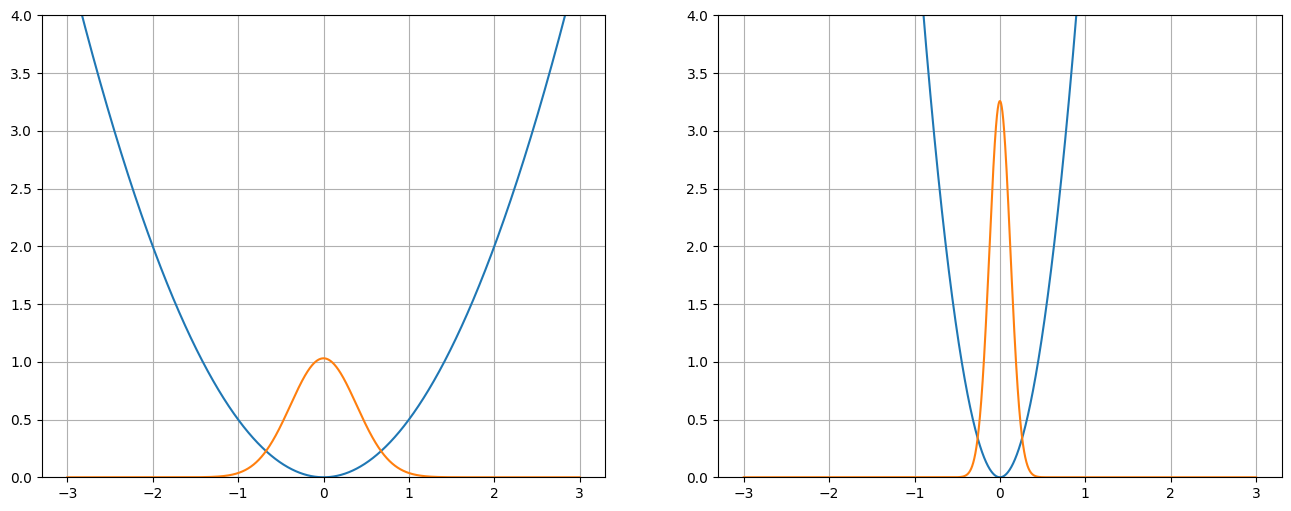

In [ ]:
harmonics = [HarmonicPotential(k=1, kT=.15, xMin=-3, xMax=3), HarmonicPotential(k=10, kT=.15, xMin=-3, xMax=3)]
xs = np.linspace(-3,3,10000)

fig, axes = plt.subplots(1,2, figsize=(16,6))

for ax, harmonic in zip(axes, harmonics):
    harmonic.plot(ax, xs)
    print(harmonic.directIntegration(xs))

0.07499999999995663
0.07375820833416555
0.07499999999999997
0.07171038189181894


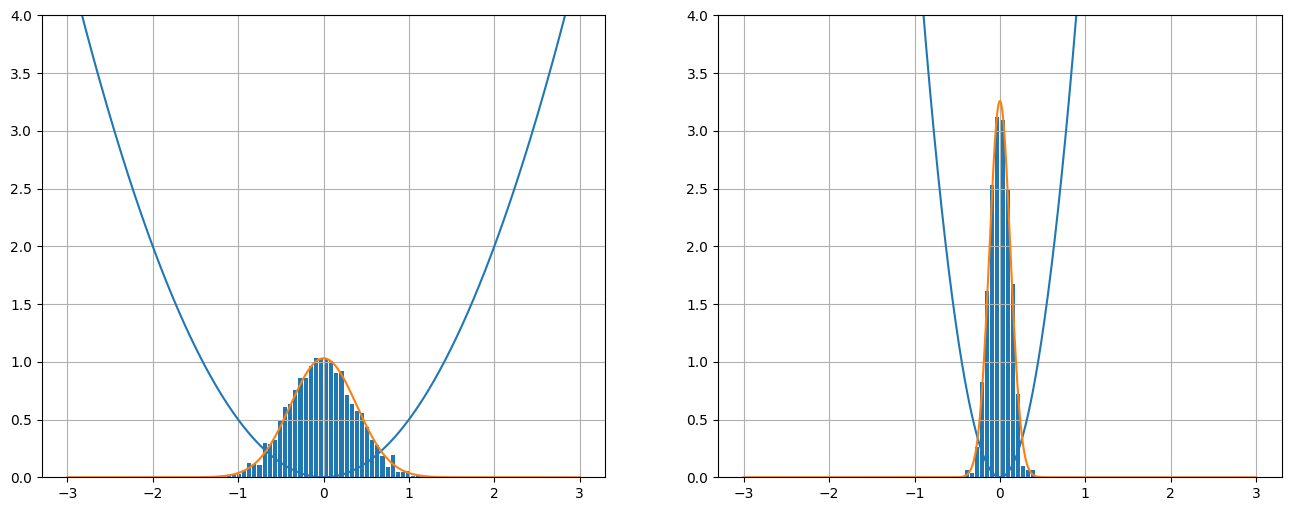

In [ ]:
harmonics = [HarmonicPotential(k=1, kT=.15, xMin=-3, xMax=3), HarmonicPotential(k=10, kT=.15, xMin=-3, xMax=3)]
sampleK1 = harmonics[0].sample()
sampleK10 = harmonics[1].sample()

fig, axes = plt.subplots(1,2, figsize=(16,6))

for ax, harmonic in zip(axes, harmonics):
    sample = harmonic.sample()
    harmonic.plot(ax, xs, sample=sample, xwidth=.06)
    print(harmonic.directIntegration(xs))
    print(harmonic.averageFromSample(sample))

In [ ]:
kTs = np.linspace(.15, 1, 10)
xs = np.linspace(-3,3,1000)
V_avgs = []

for kT in kTs:
    h = HarmonicPotential(k=1, kT=kT, xMin=-3, xMax=3)
    V_avg = h.directIntegration(xs)
    V_avgs.append(V_avg)

C_v = np.gradient(V_avgs, kTs)
print(C_v)

[0.49999994 0.49999369 0.49987113 0.49909402 0.49651497 0.49085017
 0.48136552 0.46810213 0.45166968 0.44276253]
